In [1]:
%reload_ext autoreload
%autoreload 2

In [16]:

import blackjax

from typing import Callable, NamedTuple, Optional

import jax
import jax.numpy as jnp

# Set device to CPU
jax.config.update("jax_platform_name", "cpu")

import matplotlib.pyplot as plt

from blackjax.smc.resampling import systematic
from blackjax.smc.ess import ess

from probjax.inference.filtering.particle_filter import ParticleFilter

In [17]:
from probjax.inference.smc.resampling import resample_ot, resample_systematic, resample_smoothed

In [18]:

N = 1000
particles = jax.random.normal(jax.random.PRNGKey(0), (N,1))
weights = jax.scipy.stats.norm.pdf(particles, loc=0.0, scale=0.1).sum(axis=1)
weights = weights / jnp.sum(weights)


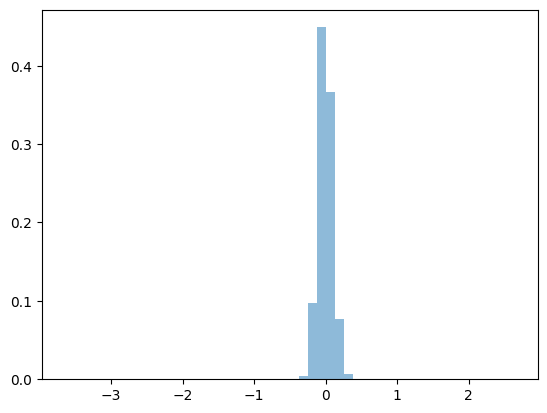

In [19]:
# new_particles, new_log_weights,_ = resample_systematic(jax.random.PRNGKey(0), jnp.log(weights), particles)
# new_particles, new_log_weights,_ = resample_ot(jax.random.PRNGKey(0), jnp.log(weights), particles, eps=0.5, inner_iterations=1, max_iter=2)
new_particles, new_log_weights,_ = resample_smoothed(jax.random.PRNGKey(0), jnp.log(weights), particles, alpha=0.8)

_ = plt.hist(new_particles.flatten(), bins=50, alpha=0.5, weights=jnp.exp(new_log_weights), label="Resampled")

In [20]:
jnp.exp(new_log_weights).sum()

Array(1.0000002, dtype=float32)

In [21]:
key = jax.random.PRNGKey(0)

In [174]:
A = 1.1  # State transition coefficient
H = 1.0   # Observation matrix
Q = 0.1    # Process noise variance
R = 0.01   # Measurement noise variance

def log_likelihood_fn(x,y,t):
    return jax.scipy.stats.norm.logpdf(y,H* x, R)

def transition_fn(key,x,t):
    return A*x + jnp.sqrt(Q)*jax.random.normal(key, shape=x.shape)

In [175]:
def simulate(key, x0, ts):
    x = jnp.asarray(x0)
    xs = [x]
    for t in ts[1:]:
        key, subkey = jax.random.split(key)
        x = transition_fn(subkey, x, t)
        xs.append(x)
    
    return jnp.stack(xs)

In [176]:
num_time_points = 50
ts = jnp.linspace(0, 50, num_time_points)
xs = jax.vmap(simulate, in_axes=(0,None,None))(jax.random.split(key, 100), 0., ts)

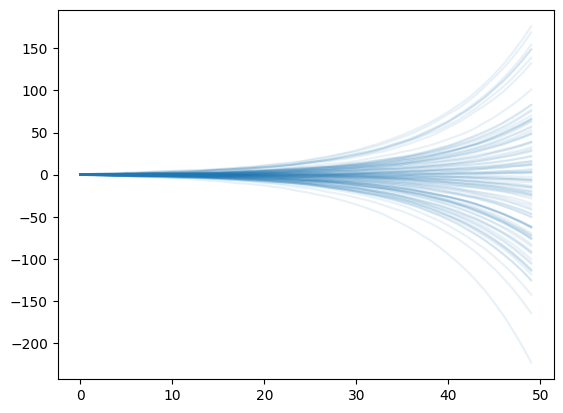

In [177]:
_ = plt.plot(xs.T, alpha=0.1, color="C0")

In [178]:
xs.shape

(100, 50)

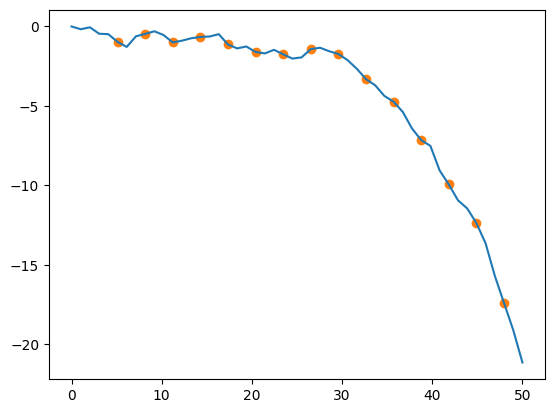

In [179]:
observe_every = 3
start_at = 5
x_o = xs[0,start_at::observe_every]
t_o = ts[start_at::observe_every]
plt.scatter(t_o, x_o, color="C1")
plt.plot(ts, xs[0,:], color="C0")

In [180]:
from probjax.inference.filter import filter, filter_log_likelihood

(1000,)


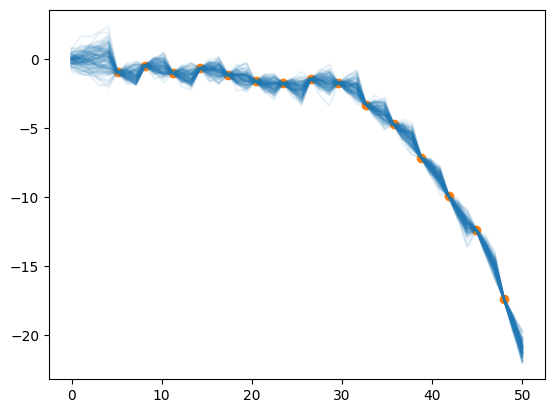

In [181]:
#resample = lambda *args: resample_ot(*args, min_iter=3,max_iter=3, eps=0.5, inner_iterations=3)
resample = lambda *args: resample_systematic(*args)
#resample = lambda *args: resample_smoothed(*args, alpha=0.8)
#kernel = jax.jit(build_kernel(log_likelihood_fn,transition_fn,resample_fn=resample, unbiased_gradients=False))
kernel = ParticleFilter(log_likelihood_fn,transition_fn, resample_criterion=lambda x: True)
particles = jnp.zeros((N,))
filtered_particles = filter(jax.random.PRNGKey(0), ts, t_o, x_o, kernel, particles)
plt.plot(ts, filtered_particles[:,:100], alpha=0.1, color="C0")
plt.scatter(t_o,x_o, color="C1")

In [182]:
def build_log_posterior_density_fn(ts, t_o, x_o):
    
    
    def log_posterior_density_fn(A, key):
        key1, key2 = jax.random.split(key)
        particles = jnp.zeros((1000,))
        def transition_fn(key,x,t):
            return A*x + jnp.sqrt(Q)*jax.random.normal(key, shape=x.shape)
        kernel = ParticleFilter(log_likelihood_fn,transition_fn)
        log_Z = filter_log_likelihood(key2, ts, t_o, x_o, kernel, particles)
        return log_Z.sum() + jax.scipy.stats.norm.logpdf(A).sum()
    
    return log_posterior_density_fn

In [183]:
from probjax.inference.kernels.slice import slice

In [184]:
log_density_fn = jax.jit(build_log_posterior_density_fn(ts, t_o, x_o))

In [185]:
def key_proposal(key):
    return jax.random.split(key)[-1]

def key_logpdf(*input):
    return 1.

A0 = jnp.array([0.1])
rng0 = jax.random.PRNGKey(1)

log_density_fn1 = lambda A: log_density_fn(A, rng0)
state1 = slice.init(A0, log_density_fn1, jax.random.PRNGKey(1))
log_density_fn2 = lambda key: log_density_fn(state1.position, key)
state2 = blackjax.irmh.init(key, log_density_fn2)

kernel1 = slice.build_kernel()
kernel2 = blackjax.irmh.build_kernel()

@jax.jit
def latent_gibbs(key, state1, state2):
    subkey1, subkey2 = jax.random.split(key,2)
    log_density_fn1 = lambda x: log_density_fn(x, state2.position)
    state1, info1 = kernel1(subkey1, state1, log_density_fn1, step_size=1e-1)

    log_density_fn2 = lambda x: log_density_fn(state1.position, x)
    state2, info2 = kernel2(subkey2, state2, log_density_fn2, proposal_distribution=key_proposal)

    return (state1, state2), (info1, info2)
    



(1000,)


In [186]:
samples = []
for i in range(5000):
    key, subkey = jax.random.split(key)
    (state1, state2), (info1, info2) = latent_gibbs(subkey, state1, state2)
    samples.append(state1.position)

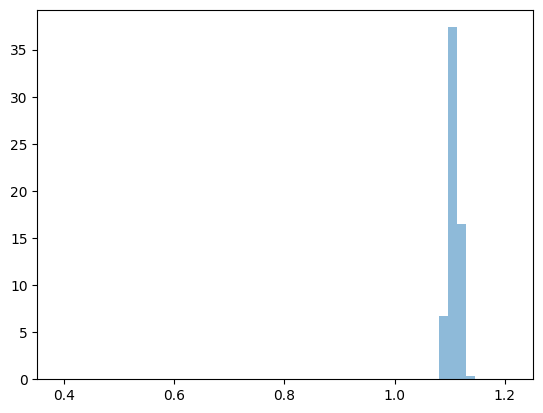

In [187]:
_ = plt.hist(jnp.concatenate(samples), bins=50, alpha=0.5, density=True)

In [188]:
state1.position

Array([1.109338], dtype=float32)

In [189]:
As = jnp.linspace(-1.5, 1.5, 100)

In [190]:
keys = jax.random.split(jax.random.PRNGKey(0), 100)

(1000,)


(-10000.0, 100.0)

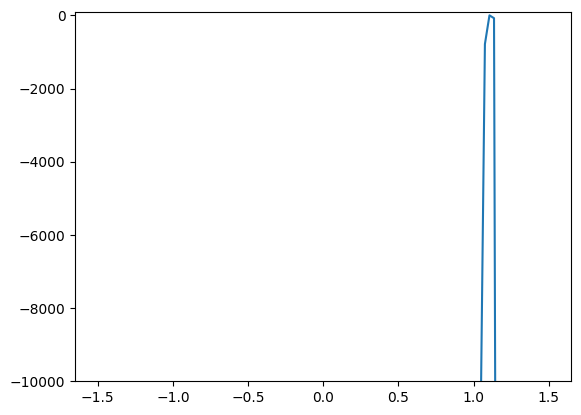

In [191]:
marginal_log_likelihood_estimate = jax.vmap(log_density_fn)(As, keys)
plt.plot(As,marginal_log_likelihood_estimate - jax.scipy.special.logsumexp(marginal_log_likelihood_estimate), label="Marginal likelihood estimate")
plt.ylim(-10000, 100)

(-10000.0, 100.0)

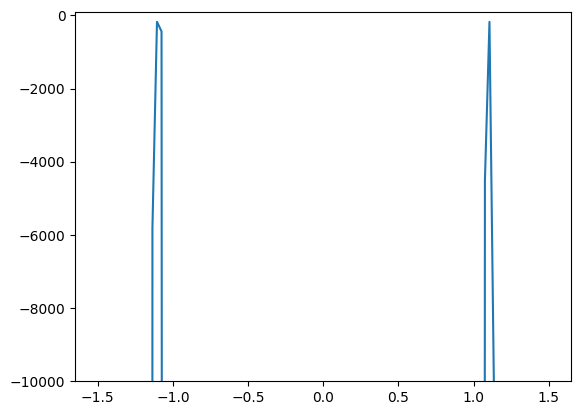

In [159]:
# Fixed random key!
marginal_log_likelihood_estimate = jax.vmap(log_density_fn, in_axes=(0,None))(As, key)
plt.plot(As,marginal_log_likelihood_estimate)
plt.ylim(-10000, 100)

In [33]:
grad_fn = jax.grad(log_density_fn)

In [34]:
marginal_log_likelihood_grad = jax.vmap(grad_fn)(As, keys, jax.random.normal(jax.random.PRNGKey(0), (100,200,)))

(-100.0, 100.0)

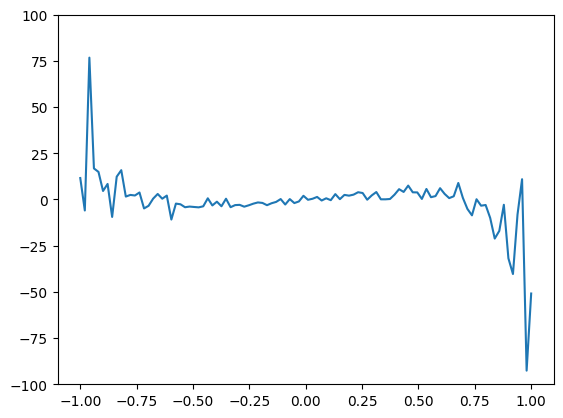

In [35]:
plt.plot(As,marginal_log_likelihood_grad)
plt.ylim(-100, 100)

In [19]:
sequence = [state]
y_os = jax.random.normal(key, shape=(500,))
j = 0
obs_i = []
for i in range(500):
    key, key_sample = jax.random.split(key)
    if (i) % 50 != 1:
        new_state, _ = kernel(key_sample, sequence[-1], 0)
    else:
        new_state, _ = kernel(key_sample, sequence[-1], y_os[j], 0)
        j += 1
        obs_i.append(i)
    sequence.append(new_state)

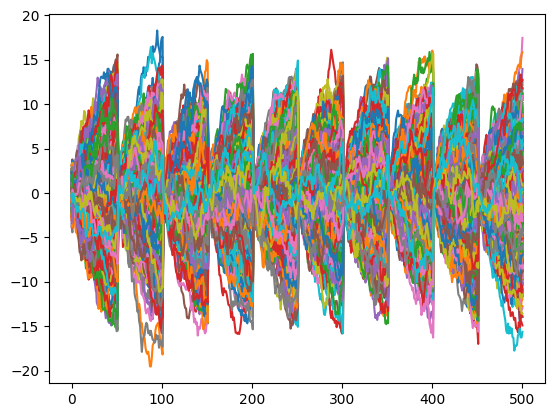

In [8]:
traces = jnp.array([s.particles for s in sequence])
_ = plt.plot(traces)

In [4]:
class ParticleFilterState(NamedTuple):
    particles: jnp.ndarray
    log_weights: jnp.ndarray
    ancestors: jnp.ndarray
    time: int

class ParticleFilterInfo(NamedTuple):
    pass

In [5]:
from jax.flatten_util import ravel_pytree

In [12]:
jax.tree_util.tree_flatten((jnp.zeros((100, 1)), jnp.zeros((100, 1)), jnp.zeros((100, 1))))

([Array([[0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [

Incremental importance weight.

Assuming we use $q(x_n|x_{n-1})$ to approximate $p(x_n|x_{n-1})$, we have the following incremental importance weight:

$$ \alpha(x_n) = \frac{p(x_{1:n}|y_{1:n})}{p(x_{1:n-1}|y_{1:n-1}) p(x_n|x_{n-1})} = \frac{p(x_n|x_{n-1}) p(y_n|x_{n})}{p(x_n|x_{n-1})p(y_n|y_{n-1})} $$ 

In [4]:
def init(particles):
    weights = jnp.ones((particles.shape[0],)) / particles.shape[0]
    idx = jnp.arange(particles.shape[0])
    return ParticleFilterState(particles, weights,idx, 0)

def build_kernel(
    log_likelihood_fn: Callable,
    transition_fn: Callable,
    resample_criterion: Callable,
    resample_fn: Callable,
    ):
    
    def kernel(
        rng_key,
        state: ParticleFilterState,
        observed = None,
    ):
        particles = state.particles
        weights = state.weights
        
        # Predict
        new_particles = transition_fn(rng_key, particles, state.time)
        
        # Update
        if observed is not None:
            log_weights = log_likelihood_fn(new_particles, observed) + jnp.log(weights)
            log_weights = log_weights - jnp.max(log_weights)
            new_weights = jax.nn.softmax(log_weights)
            
            # Resample
            if resample_criterion(state):
                idx = resample_fn(rng_key, new_weights, particles.shape[0])
                new_particles = particles[idx]
                new_weights = jnp.ones_like(new_weights) / particles.shape[0]
            else:
                idx = state.ancestors
        else:
            new_weights = weights
            idx = state.ancestors
            
 

        return ParticleFilterState(new_particles, new_weights, idx,state.time + 1), ParticleFilterInfo()
    
    return kernel

In [16]:
A = 1.  # State transition coefficient
H = 1.0   # Observation matrix
Q = 0.5    # Process noise variance
R = 0.01   # Measurement noise variance

def log_likelihood_fn(x,y):
    return jax.scipy.stats.norm.logpdf(y,H* x, R)

def transition_fn(key,x,index):
    return jnp.sqrt(Q)*jax.random.normal(key, shape=x.shape) + A*x


In [17]:
key = jax.random.PRNGKey(0)
state = init(jax.random.normal(key, (100,)))
kernel = build_kernel(log_likelihood_fn, transition_fn, ,systematic)

NameError: name 'resample_criterium' is not defined

In [22]:
sequence = [state]
y_os = jax.random.normal(key, shape=(50,))
j = 0
obs_i = []
for i in range(100):
    key, key_sample = jax.random.split(key)
    if (i) % 3 != 1:
        new_state, _ = kernel(key_sample, sequence[-1])
    else:
        new_state, _ = kernel(key_sample, sequence[-1], y_os[j])
        j += 1
        obs_i.append(i)
    sequence.append(new_state)

100.0
1.0077858
100.0
1.0
100.0
1.0
100.0
1.1213613
100.0
1.0
100.0
1.0
100.0
1.0171225
100.0
2.6923404
100.0
1.7396247
100.0
1.7183952
100.0
1.0008125
100.0
1.3401583
100.0
1.0
100.0
1.3474422
100.0
1.0029361
100.0
1.2081912
100.0


In [23]:
traces = jnp.array([s.particles for s in sequence])
ancestors = jnp.array([s.ancestors for s in sequence])
weights = jnp.array([s.weights for s in sequence])

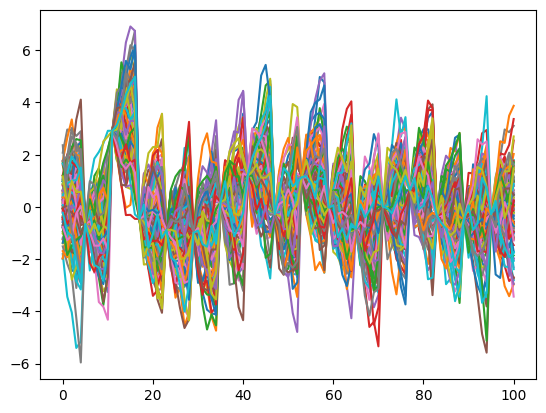

In [24]:
plt.plot(traces)

In [9]:
# reconstruct the path of the particles
path = [traces[-1,:]]
current_ancestors = ancestors[-1]
for i in range(len(ancestors)-1, 0, -1):
    if all(current_ancestors != ancestors[i-1]):
        current_ancestors = ancestors[i-1]
        path.append(traces[i, current_ancestors])
    else:
        path.append(traces[i,:])
path = jnp.array(path)

/tmp/ipykernel_3839/2368894176.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = plt.cm.get_cmap('viridis', 256)


ValueError: array([[0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  , 0.223549  , 0.512008  , 0.16470588],
       [0.267968  ,

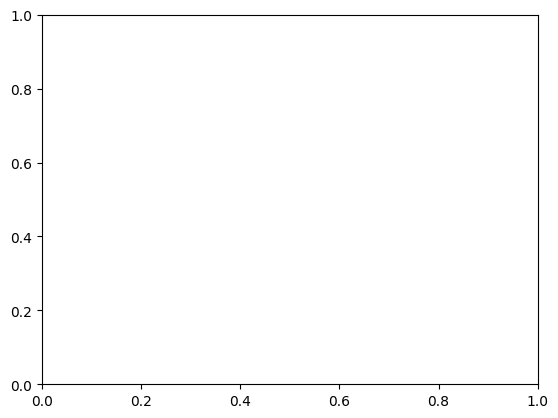

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Get the 'viridis' colormap
viridis = plt.cm.get_cmap('viridis', 256)

# Create a new colormap where the alpha value varies linearly
newcolors = viridis(np.linspace(0, 1, 256))
alphas = np.linspace(0, 1, 256)
newcolors[:, -1] = alphas
cmap = mcolors.ListedColormap(newcolors)

# Now you can use `newcmp` as your colormap
weights = weights / weights.max()

for i in range(traces.shape[1]):
    # Get the RGBA color from the colormap
    rgba = cmap(weights[i])
    
    # Use the alpha channel as the transparency of the line
    plt.plot(path[:, i], c=rgba)

plt.scatter(obs_i, y_os[:len(obs_i)], color="red")

plt.show()

In [482]:
import numpy as np

# Parameters
A = 1.001  # State transition coefficient
H = 1.0   # Observation matrix
Q = 1.   # Process noise variance
R = 0.   # Measurement noise variance
num_particles = 1000
num_steps = 100

# Initialization
particles = np.random.normal(0, np.sqrt(Q), num_particles)
weights = np.full(num_particles, 1.0 / num_particles)

# Simulate some data
true_states = np.zeros(num_steps)
observations = np.zeros(num_steps)
true_states[0] = np.random.normal(0, np.sqrt(Q))
observations[0] = H * true_states[0] + np.random.normal(0, np.sqrt(R))
for t in range(1, num_steps):
    true_states[t] = A * true_states[t - 1] + np.random.normal(0, np.sqrt(Q))
    observations[t] = H * true_states[t] + np.random.normal(0, np.sqrt(R))

filtered_particles = np.zeros((num_steps, num_particles))
# Forward Filtering
for t in range(1, num_steps):
    particles = A * particles + np.random.normal(0, np.sqrt(Q), num_particles)
    weights *= [np.exp(-0.5 * ((observations[t] - H * p) ** 2) / R) for p in particles]
    weights /= np.sum(weights)
    # Resampling
    indices = np.random.choice(range(num_particles), num_particles, p=weights)
    particles = particles[indices]
    weights.fill(1.0 / num_particles)
    filtered_particles[t] = particles

# Backward Smoothing
smoothed_particles = np.zeros((num_steps, num_particles))
smoothed_particles[-1] = particles
for t in range(num_steps - 2, -1, -1):
    for i in range(num_particles):
        ancestor = np.random.choice(range(num_particles), p=weights)
        smoothed_particles[t, i] = A * smoothed_particles[t + 1, ancestor] + np.random.normal(0, np.sqrt(Q))

# Estimate the smoothed states
smoothed_states = np.mean(smoothed_particles, axis=1)
smoothed_var = np.var(smoothed_particles, axis=1)

filtered_states = np.mean(filtered_particles, axis=1)

In [490]:
import numpy as np

# Parameters
A = 1.  # State transition coefficient
H = 1.0   # Observation matrix
Q = 0.5    # Process noise variance
R = 0.01   # Measurement noise variance
num_particles = 1000
num_steps = 1000
observation_interval = 300  # Observations are made every 10 steps

# Initialization
particles = np.random.normal(0, np.sqrt(Q), num_particles)
weights = np.full(num_particles, 1.0 / num_particles)

# Simulate some data
true_states = np.zeros(num_steps)
observations = np.full(num_steps, np.nan)  # Initialize observations as NaN
true_states[0] = np.random.normal(0, np.sqrt(Q))
observations[0] = H * true_states[0] + np.random.normal(0, np.sqrt(R))
for t in range(1, num_steps):
    true_states[t] = A * true_states[t - 1] + np.random.normal(0, np.sqrt(Q))
    if t % observation_interval == 0:
        observations[t] = H * true_states[t] + np.random.normal(0, np.sqrt(R))

filtered_particles = np.zeros((num_steps, num_particles))
ancestor_indices = np.zeros((num_steps, num_particles), dtype=int)
weights_record = np.full((num_steps, num_particles), 1.0 / num_particles)

# Forward Filtering
for t in range(1, num_steps):
    particles = A * particles + np.random.normal(0, np.sqrt(Q), num_particles)
    if not np.isnan(observations[t]):
        weights *= np.exp(-0.5 * ((observations[t] - H * particles) ** 2) / R)
        weights /= np.sum(weights)
        weights_record[t] = weights  # Record the weights at observation times
        indices = np.random.choice(range(num_particles), num_particles, p=weights)
        particles = particles[indices]
        ancestor_indices[t] = indices
        weights.fill(1.0 / num_particles)
    filtered_particles[t] = particles

# Backward Smoothing
# Backward Smoothing
smoothed_particles = np.zeros((num_steps, num_particles))
smoothed_particles[-1, :] = filtered_particles[-1, :]

# Start from the end and move backwards
for t in range(num_steps - 2, -1, -1):
    # Compute weights for each particle at time t
    weights_backward = np.zeros(num_particles)
    for i in range(num_particles):
        # Here we calculate the transition probability density of each particle at t given the
        # smoothed particle at t+1.
        weights_backward[i] = weights_record[t, i] * np.exp(
            -0.5 * ((smoothed_particles[t + 1, i] - A * filtered_particles[t, i]) ** 2) / Q)

    # Normalize the backward weights
    weights_backward /= sum(weights_backward)

    # Resample based on the backward weights
    indices = np.random.choice(num_particles, size=num_particles, p=weights_backward)
    smoothed_particles[t] = filtered_particles[t, indices]

smoothed_states = np.mean(smoothed_particles, axis=1)
smoothed_var = np.var(smoothed_particles, axis=1)

filtered_states = np.mean(filtered_particles, axis=1)
filtered_var = np.var(filtered_particles, axis=1)



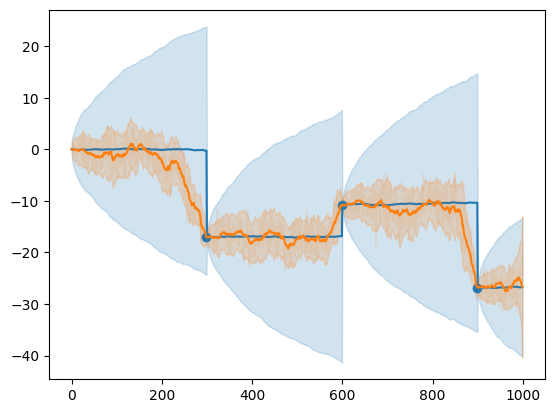

In [491]:
import matplotlib.pyplot as plt

plt.plot(observations[1:], label="True States", marker="o")
plt.plot(filtered_states, label="Filtered States", color="C0")
plt.fill_between(range(num_steps), filtered_states - 2 * np.sqrt(filtered_var), filtered_states + 2 * np.sqrt(filtered_var), alpha=0.2, color="C0")
plt.plot(smoothed_states, label="Smoothed States", color="C1")
plt.fill_between(range(num_steps), smoothed_states - 2 * np.sqrt(smoothed_var), smoothed_states + 2 * np.sqrt(smoothed_var), alpha=0.2, color="C1")
plt.plot(smoothed_particles[:,0], color="C1", alpha=0.1, label="Smoothed Particles")